# Tanzania Climate EDA
NASA POWER MERRA-2 Daily Data — Dar es Salaam (2015–2026)

## 1. Data Loading & Date Parsing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/tanzania.csv')
df['Country'] = 'Tanzania'
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
print(df.shape)
df.head()

(4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


## 2. Summary Statistics & Missing Value Report

In [2]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,2026-03-27,3
4104,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,2026-03-28,3
4105,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,2026-03-29,3
4106,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania,2026-03-30,3


In [3]:
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 0


**Duplicates:** Any duplicate rows found are dropped and documented here.

In [4]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


**Interpretation of Summary Statistics:**
- T2M averages around 26–28°C, reflecting Dar es Salaam's hot and humid coastal climate.
- RH2M is consistently high, driven by proximity to the Indian Ocean.
- PRECTOTCORR shows high variability with a pronounced rainy season.
- T2M_RANGE is small compared to Sudan, consistent with a maritime/coastal climate where the ocean moderates temperature swings.

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(missing_report[missing_report['Missing %'] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


**Missing Values:**
Columns with >5% missing values are flagged. Coastal locations generally have good satellite coverage, so missing values are expected to be minimal.

## 3. Outlier Detection & Basic Cleaning

In [6]:
climate_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = df[climate_cols].apply(lambda col: np.abs(stats.zscore(col.dropna())))
outlier_counts = (z_scores > 3).sum()
print('Outlier counts per column (|Z| > 3):')
print(outlier_counts)

Outlier counts per column (|Z| > 3):
T2M             1
T2M_MAX         2
T2M_MIN         4
PRECTOTCORR    81
RH2M            2
WS2M            8
WS2M_MAX        4
dtype: int64


**Outlier Decision:**
Outliers are retained. Extreme rainfall events along Tanzania's coast are climatically real and important for vulnerability analysis. Removing them would underrepresent flood risk.

In [7]:
df[climate_cols] = df[climate_cols].ffill()
threshold = len(df.columns) * 0.7
df.dropna(thresh=int(threshold), inplace=True)
print('Shape after cleaning:', df.shape)

Shape after cleaning: (4108, 15)


In [8]:
import os
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/tanzania_clean.csv', index=False)
print('Exported to data/tanzania_clean.csv')

Exported to data/tanzania_clean.csv


## 4. Time Series Analysis

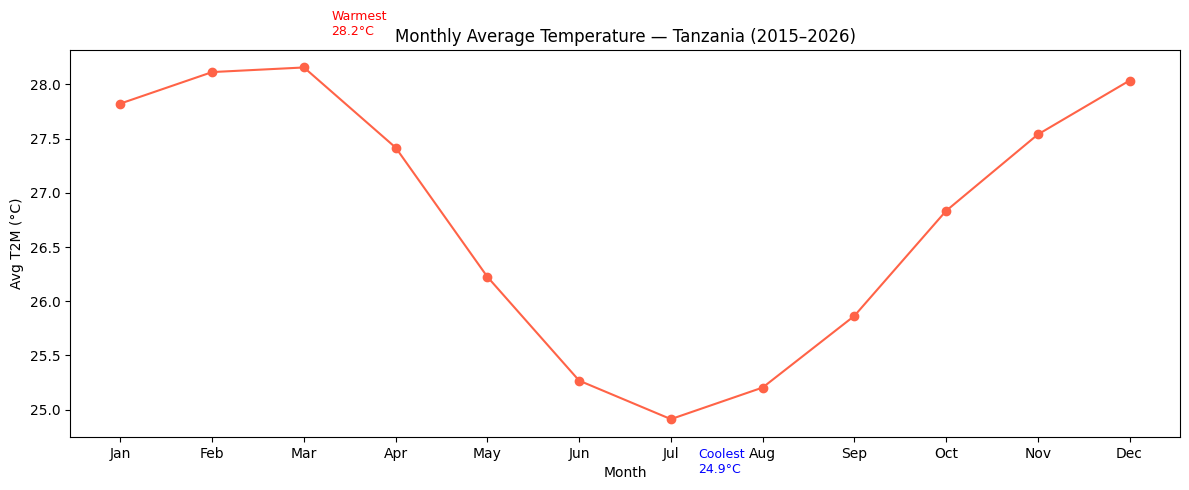

In [9]:
monthly_temp = df.groupby('Month')['T2M'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_temp.index, monthly_temp.values, marker='o', color='tomato')

warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()
ax.annotate(f'Warmest\n{monthly_temp[warmest]:.1f}°C', xy=(warmest, monthly_temp[warmest]),
            xytext=(warmest + 0.3, monthly_temp[warmest] + 0.3), fontsize=9, color='red')
ax.annotate(f'Coolest\n{monthly_temp[coolest]:.1f}°C', xy=(coolest, monthly_temp[coolest]),
            xytext=(coolest + 0.3, monthly_temp[coolest] - 0.5), fontsize=9, color='blue')

ax.set_title('Monthly Average Temperature — Tanzania (2015–2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg T2M (°C)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

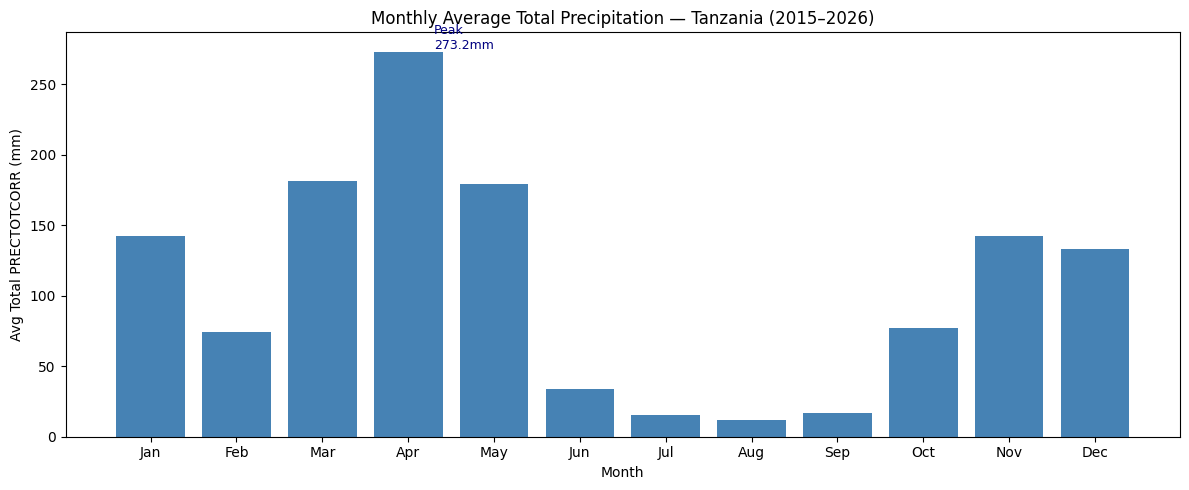

In [10]:
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum() / df['YEAR'].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_rain.index, monthly_rain.values, color='steelblue')

peak = monthly_rain.idxmax()
ax.annotate(f'Peak\n{monthly_rain[peak]:.1f}mm', xy=(peak, monthly_rain[peak]),
            xytext=(peak + 0.3, monthly_rain[peak] + 2), fontsize=9, color='navy')

ax.set_title('Monthly Average Total Precipitation — Tanzania (2015–2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Total PRECTOTCORR (mm)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

**Time Series Observations:**
- Tanzania shows a clear long rainy season (Mar–May) and a shorter rainy season (Nov–Dec), similar to Kenya.
- Temperatures are high and relatively stable year-round due to the coastal tropical location.
- The coolest months coincide with the dry season (Jun–Aug), when southerly winds bring slightly cooler air.

## 5. Correlation & Relationship Analysis

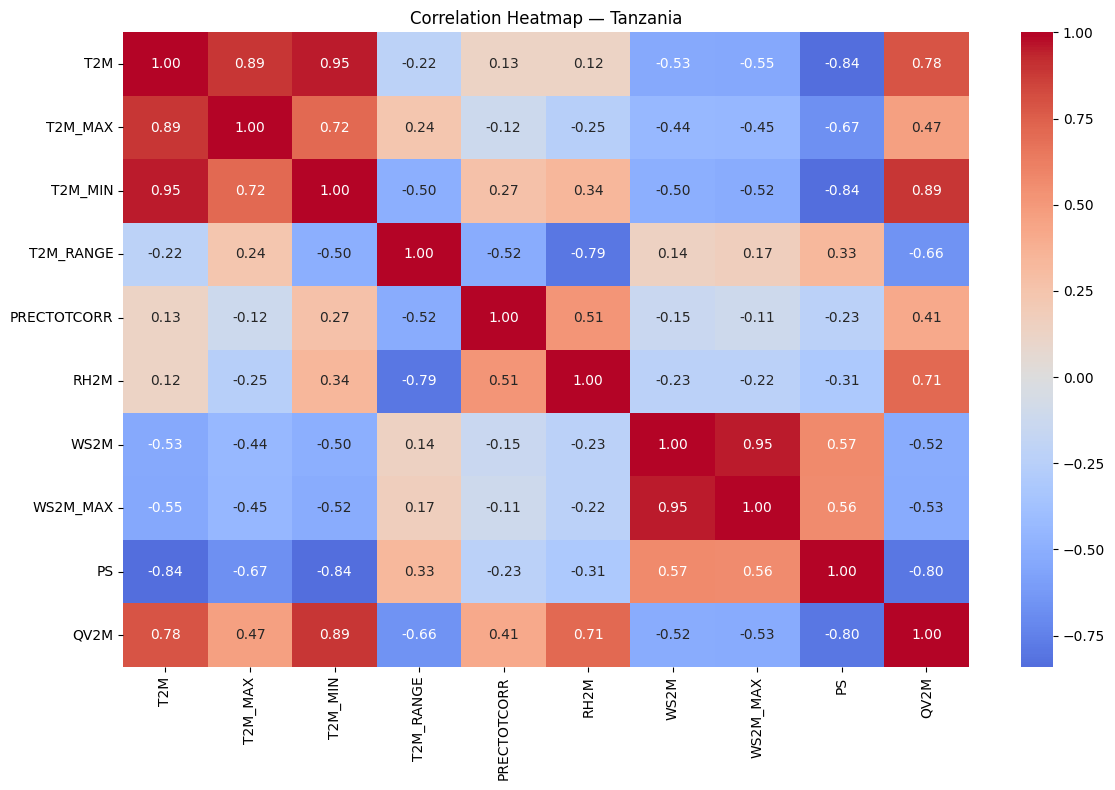

In [11]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Tanzania')
plt.tight_layout()
plt.show()

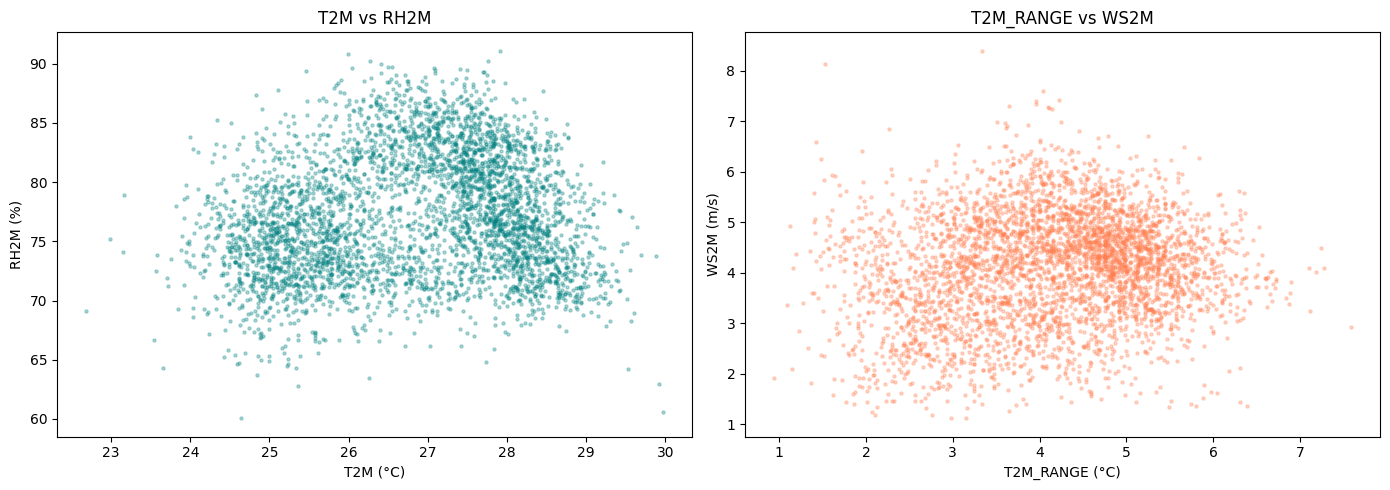

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df['T2M'], df['RH2M'], alpha=0.3, color='teal', s=5)
ax1.set_title('T2M vs RH2M')
ax1.set_xlabel('T2M (°C)')
ax1.set_ylabel('RH2M (%)')

ax2.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='coral', s=5)
ax2.set_title('T2M_RANGE vs WS2M')
ax2.set_xlabel('T2M_RANGE (°C)')
ax2.set_ylabel('WS2M (m/s)')

plt.tight_layout()
plt.show()

**Three Strongest Correlations:**
1. **T2M & T2M_MAX / T2M_MIN** — Very strong positive correlation as expected.
2. **T2M & QV2M** — Strong positive correlation; coastal humid air holds high moisture content.
3. **RH2M & QV2M** — Strong positive correlation; both measure atmospheric moisture and track together closely in humid coastal climates.

## 6. Distribution Analysis

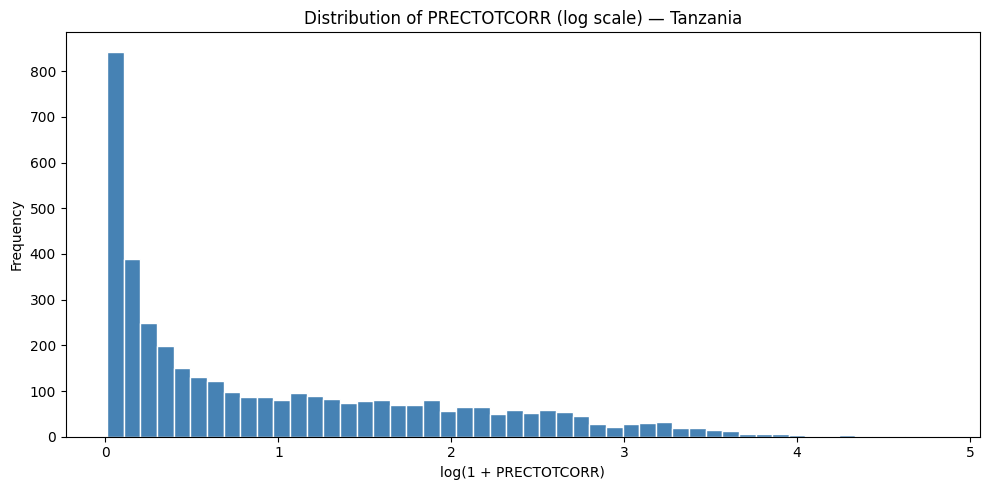

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
rain_nonzero = df['PRECTOTCORR'][df['PRECTOTCORR'] > 0]
ax.hist(np.log1p(rain_nonzero), bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution of PRECTOTCORR (log scale) — Tanzania')
ax.set_xlabel('log(1 + PRECTOTCORR)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Precipitation Distribution:**
Right-skewed in raw form. After log transformation, the distribution is more symmetric. Tanzania has more frequent and heavier rainfall days than Sudan, reflecting its coastal tropical climate with reliable monsoon seasons.

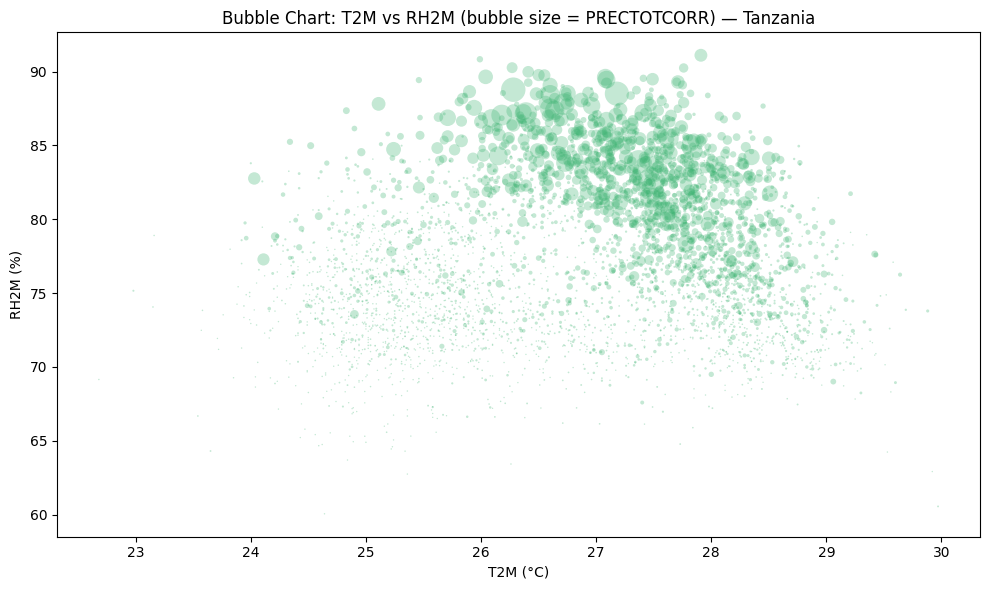

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR'] * 3 + 1,
            alpha=0.3, color='mediumseagreen', edgecolors='none')
plt.title('Bubble Chart: T2M vs RH2M (bubble size = PRECTOTCORR) — Tanzania')
plt.xlabel('T2M (°C)')
plt.ylabel('RH2M (%)')
plt.tight_layout()
plt.show()